In [2]:
import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from copy import deepcopy

from IPython.display import HTML, display

import highway_env

from stable_baselines3 import DQN

c:\Users\arfib\anaconda3\envs\RL_env\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


métriques à l'entraînement : loss, reward, episode legnth, reward moyen par episode

In [3]:
SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 100,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    # "collision_reward": -1.5,
    # "right_lane_reward": 0.0,
    # "high_speed_reward": 0.7,
    # "lane_change_reward": -0.02,
    # "reward_speed_range": [22, 30],
    # "normalize_reward": True,
    "offroad_terminal": True,
}

EVAL_SEEDS = list(range(50))  # for reproducible evaluation

def make_env(config=None, render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode, config=config)
    return env

env = make_env(SHARED_CORE_CONFIG)
obs, _ = env.reset()
print("Observation shape :", obs.shape)
print("Action space      :", env.action_space)
print("Flattened obs size:", obs.flatten().shape[0])

Observation shape : (10, 5)
Action space      : Discrete(5)
Flattened obs size: 50


In [3]:
# # env = gym.make("highway-v0", render_mode="human")
# env = make_env(SHARED_CORE_CONFIG)

# model = DQN("MlpPolicy", env, gamma=0.99, target_update_interval=200, exploration_fraction=0.5, learning_rate=1e-3, buffer_size=20_000, batch_size=64, exploration_initial_eps=0.9,exploration_final_eps=0.05,   verbose=1)
# model.learn(total_timesteps=400*30)
# model.save("dqn_stable_baseline_longer_episodes_bigger_exp_frac")

# del model # remove to demonstrate saving and loading

In [4]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

class FullMetricsCallback(BaseCallback):
    def __init__(self, eval_env_fn, eval_every=2000, n_eval_episodes=10):
        super().__init__()
        
        self.eval_env_fn = eval_env_fn
        self.eval_every = eval_every
        self.n_eval_episodes = n_eval_episodes

        # stockage
        self.episode_rewards = []
        self.episode_lengths = []

        self.eval_steps = []
        self.eval_means = []
        self.eval_stds = []

    def _on_step(self) -> bool:
        # ---- récupérer épisodes finis (via Monitor)
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])

        # ---- évaluation périodique
        if self.n_calls % self.eval_every == 0:
            rewards = []

            for i in range(self.n_eval_episodes):
                env = self.eval_env_fn()
                obs, _ = env.reset(seed=i)
                done = False
                ep_reward = 0

                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, reward, terminated, truncated, _ = env.step(action)
                    ep_reward += reward
                    done = terminated or truncated

                rewards.append(ep_reward)
                env.close()

            rewards = np.array(rewards)

            self.eval_steps.append(self.n_calls)
            self.eval_means.append(rewards.mean())
            self.eval_stds.append(rewards.std())

        return True

In [20]:
env=gym.make("highway-v0")
print(env.unwrapped.config) 

{'observation': {'type': 'Kinematics'}, 'action': {'type': 'DiscreteMetaAction'}, 'simulation_frequency': 15, 'policy_frequency': 1, 'other_vehicles_type': 'highway_env.vehicle.behavior.IDMVehicle', 'screen_width': 600, 'screen_height': 150, 'centering_position': [0.3, 0.5], 'scaling': 5.5, 'show_trajectories': False, 'render_agent': True, 'offscreen_rendering': False, 'manual_control': False, 'real_time_rendering': False, 'lanes_count': 4, 'vehicles_count': 50, 'controlled_vehicles': 1, 'initial_lane_id': None, 'duration': 40, 'ego_spacing': 2, 'vehicles_density': 1, 'collision_reward': -1, 'right_lane_reward': 0.1, 'high_speed_reward': 0.4, 'lane_change_reward': 0, 'reward_speed_range': [20, 30], 'normalize_reward': True, 'offroad_terminal': False}


In [19]:
import tensorboard

# env = gym.make("highway-v0", render_mode="human")
env = make_env(SHARED_CORE_CONFIG)
# model = DQN(
#     "MlpPolicy",
#     env,
#     learning_rate=1e-4,
#     buffer_size=200_000,
#     learning_starts=5000,
#     batch_size=64,
#     gamma=0.99,
#     train_freq=4,
#     target_update_interval=1000,
#     exploration_fraction=0.1,
#     exploration_initial_eps=1.0,
#     exploration_final_eps=0.02,
#     policy_kwargs=dict(net_arch=[256, 256]),
#     verbose=1
# )
model = DQN('MlpPolicy', env,
              policy_kwargs=dict(net_arch=[256, 256]),
              learning_rate=1e-3,
              buffer_size=20000,
              learning_starts=200,
              batch_size=64,
              gamma=0.8,
              train_freq=(1, "step"),
              gradient_steps=1,
              target_update_interval=50,
              verbose=1,
              tensorboard_log="highway_dqn/")

callback = FullMetricsCallback(
    eval_env_fn=lambda: make_env(SHARED_CORE_CONFIG),
    eval_every=2000,
    n_eval_episodes=10
)
# model.learn(int(200), callback=callback)
model.learn(int(20000), callback=callback)
# model.learn(total_timesteps=400*30)
model.save("dqn_stable_baseline_test")

del model # remove to demonstrate saving and loading

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to highway_dqn/DQN_7
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 14       |
|    ep_rew_mean      | 10.7     |
|    exploration_rate | 0.973    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2        |
|    time_elapsed     | 21       |
|    total_timesteps  | 56       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 11.2     |
|    ep_rew_mean      | 8.35     |
|    exploration_rate | 0.957    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2        |
|    time_elapsed     | 32       |
|    total_timesteps  | 90       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 11.2     |
| 

In [5]:
from tensorboard.backend.event_processing import event_accumulator

ea = event_accumulator.EventAccumulator("highway_dqn/DQN_7")
ea.Reload()

# liste des tags disponibles
print(ea.Tags()['scalars'])

['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'rollout/exploration_rate', 'time/fps', 'train/learning_rate', 'train/loss']


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_training_curves(ep_rewards, rewards_steps, losses, losses_steps, eval_steps=None, eval_means=None, eval_stds=None,
                         reward_smooth_window=20, loss_smooth_window=3, save_path=None):
    """
    Plot training curves for episode rewards and TD loss, with optional evaluation metrics.

    Parameters
    ----------
    ep_rewards : list or np.array
        Rewards per episode.
    losses : list or np.array
        TD loss values per update step.
    eval_steps : list or np.array, optional
        Steps at which evaluation was performed.
    eval_means : list or np.array, optional
        Mean rewards from evaluation.
    eval_stds : list or np.array, optional
        Std of rewards from evaluation.
    reward_smooth_window : int
        Window size for smoothing episode rewards.
    loss_smooth_window : int
        Window size for smoothing TD loss.
    save_path : str or None
        Path to save figure. If None, figure is not saved.
    """

    def smooth(x, window=20):
        """Running mean for smoother visualisation."""
        return np.convolve(x, np.ones(window)/window, mode='valid')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # -----------------------
    # Episode rewards
    # -----------------------
    ax = axes[0]
    ax.plot(rewards_steps, ep_rewards, alpha=0.3, color='steelblue', label='per-episode')
    if len(ep_rewards) >= reward_smooth_window:
        smoothed_rewards = smooth(ep_rewards, reward_smooth_window)
        smoothed_steps = rewards_steps[reward_smooth_window - 1:]

        ax.plot(smoothed_steps, smoothed_rewards,
                color='steelblue', lw=2,
                label=f'smoothed ({reward_smooth_window})')
    
    # Optional evaluation metrics
    if eval_steps is not None and eval_means is not None:
        ax.errorbar(eval_steps, eval_means,
                    yerr=eval_stds if eval_stds is not None else None,
                    fmt='o--', color='tomato', capsize=4,
                    label='eval mean ± std')
    
    ax.set_xlabel('Steps')
    ax.set_ylabel('Reward')
    ax.set_title('DQN — Episode Rewards')
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(losses_steps, losses, alpha=0.2, color='orange')
    if len(losses) >= loss_smooth_window:
        smoothed_losses = smooth(losses, loss_smooth_window)
        smoothed_steps = losses_steps[loss_smooth_window - 1:]
        ax.plot(smoothed_steps, smoothed_losses,
                color='darkorange', lw=2)
    ax.set_xlabel('Update step')
    ax.set_ylabel('MSE Loss')
    ax.set_title('DQN — TD Loss')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=120)
    plt.show()

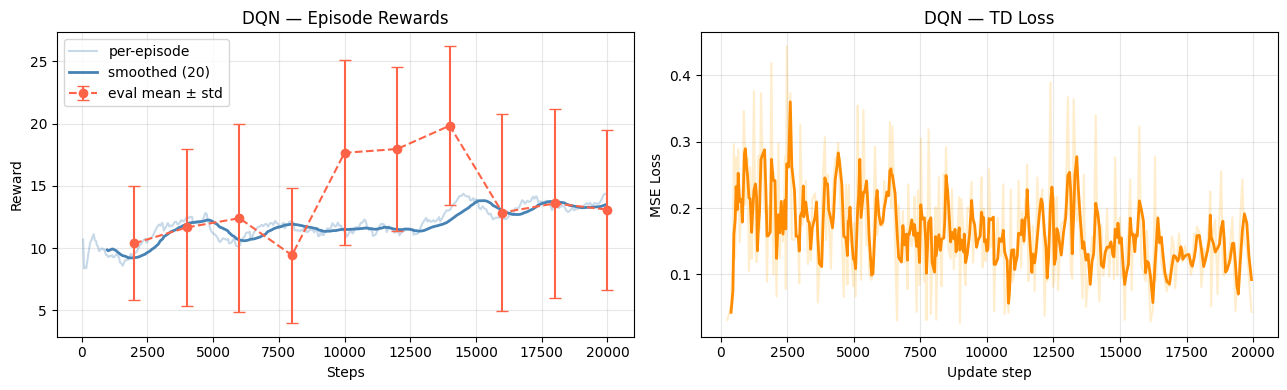

In [47]:
train_loss_events = ea.Scalars('train/loss')  # reward moyen
train_loss_values = [e.value for e in train_loss_events]
train_loss_steps=[e.step for e in train_loss_events]

rewards_events = ea.Scalars('rollout/ep_rew_mean')
rewards_values=[e.value for e in rewards_events]
rewards_steps=[e.step for e in rewards_events]

length_events=ea.Scalars('rollout/ep_len_mean') 
length_values=[e.value for e in length_events]

plot_training_curves(
    ep_rewards=rewards_values,
    rewards_steps=rewards_steps,
    losses=train_loss_values,
    losses_steps=train_loss_steps,
    eval_steps=callback.eval_steps,
    eval_means=callback.eval_means,
    eval_stds=callback.eval_stds,
    save_path="dqn_training_curves.png"
)

In [7]:
ACTION_LABELS = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}

def run_episode(model, config, seed=42):
    env = make_env(config, render_mode="rgb_array")
    env.reset(seed=seed)
    env.step(env.action_space.sample())
    obs, _ = env.reset(seed=seed)

    def get_frame(env):
        return env.render()

    frames, actions, rewards = [], [], []
    done = False

    while not done:
        action, _states = model.predict(obs, deterministic=True)
        print(action)
        obs, r, terminated, truncated, _ = env.step(action)
        frame = get_frame(env)
        if frame is not None:
            frames.append(frame)
            actions.append(int(action))
            rewards.append(r)
        done = terminated or truncated

    env.close()

    if not frames:
        raise RuntimeError(
            f"All 3 render strategies failed. "
            f"highway_env={highway_env.__version__}. "
            f"Run the diagnostic cell above and share the output."
        )

    return frames, actions, rewards, terminated


In [8]:
def make_animation(frames, actions, rewards, title, fps=10):
    """Return an HTML5 video animation."""
    if not frames:
        raise ValueError(f"No frames to animate for '{title}'. Re-run cell 5.")

    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.axis("off")
    img_obj = ax.imshow(frames[0])

    cumulative = np.cumsum(rewards)
    title_obj = ax.set_title("", fontsize=11)

    def update(i):
        img_obj.set_data(frames[i])
        action_label = ACTION_LABELS.get(actions[i], str(actions[i])) if i < len(actions) else "-"
        title_obj.set_text(
            f"{title}   |   step {i+1}/{len(frames)}   "
            f"|   action: {action_label}   "
            f"|   step_r: {rewards[i]:.3f}   "
            f"|   cum_r: {cumulative[i]:.3f}"
        )
        return img_obj, title_obj

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=1000 // fps, blit=True
    )
    plt.close(fig)
    return ani


In [ ]:
model = DQN.load("dqn_stable_baseline_")

frames_after, actions_after, rewards_after, crashed_after = run_episode(
    model, SHARED_CORE_CONFIG, seed=5
)

0
4
4
4
4
4
4
4
4
0
3
3
3
3
3


In [54]:
ani_after = make_animation(
    frames_after, actions_after, rewards_after,
    title="TRAINED (ε=0)", fps=10
)
HTML(ani_after.to_jshtml())